# Завдання 1
З вказаного сайту я обрав та завантажив датасет Heart Disease, який повністю відповідає вимогам

# Завдання 2
Здійснити Data Cleaning

In [21]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 
           'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

file_path = r'dataset\processed.cleveland.data'

if os.path.exists(file_path):
    df = pd.read_csv(file_path, names=columns, na_values='?')
    
    print(f"Кількість пропусків до DATA CLEANING: {df.isnull().sum().sum()}")
    
    # --- DATA CLEANING ---
    df['ca'] = df['ca'].fillna(df['ca'].median())
    df['thal'] = df['thal'].fillna(df['thal'].mode()[0])
    df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)
    df.drop_duplicates(inplace=True)

    print(f"Кількість пропусків після DATA CLEANING: {df.isnull().sum().sum()}")

    display(df.head())

Кількість пропусків до DATA CLEANING: 6
Кількість пропусків після DATA CLEANING: 0


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


# Завдання 3
Побудувати графіки залежності одного integer/real атрибута від іншого (lineplot, scatter etc)

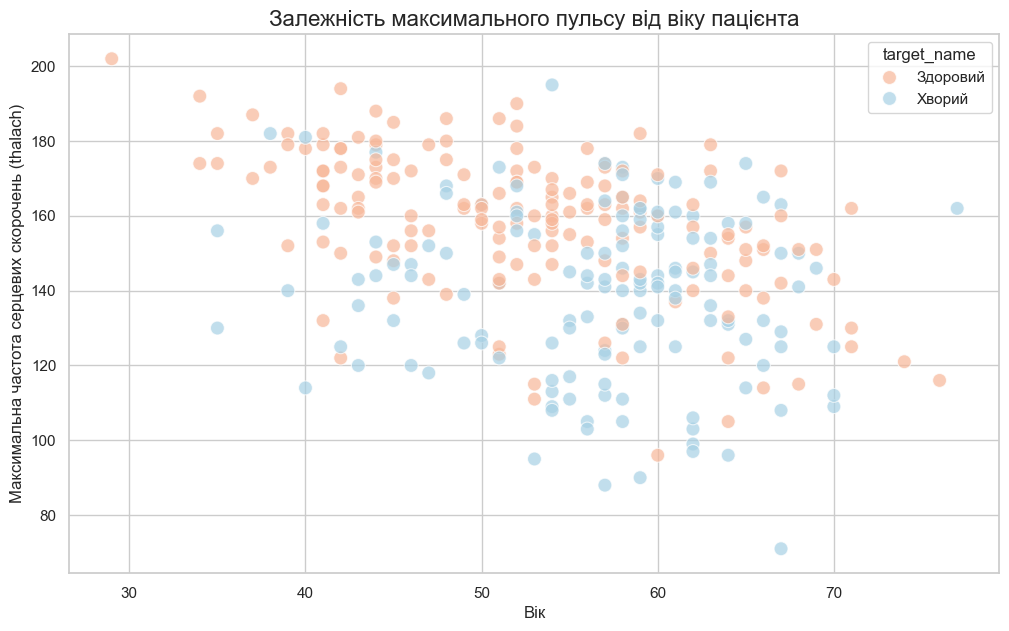

In [25]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

df['target_name'] = df['target'].map({0: 'Здоровий', 1: 'Хворий'})

scatter = sns.scatterplot(data=df, x='age', y='thalach', 
                         hue='target_name', palette='RdBu', s=100, alpha=0.7)

plt.title('Залежність максимального пульсу від віку пацієнта', fontsize=16)
plt.xlabel('Вік', fontsize=12)
plt.ylabel('Максимальна частота серцевих скорочень (thalach)', fontsize=12)

df.drop(columns=['target_name'], inplace=True)

plt.show()

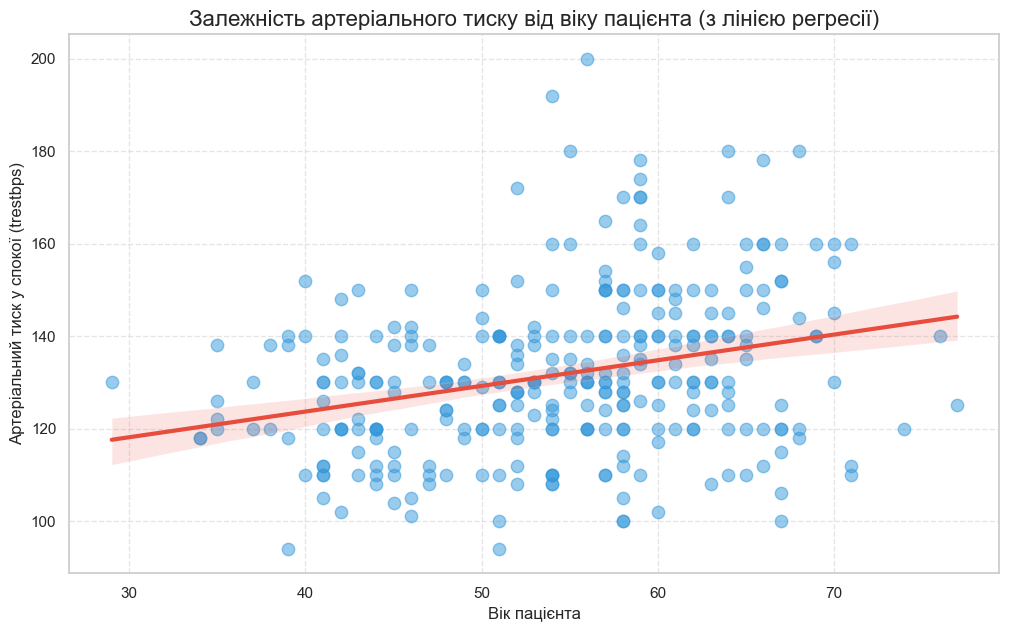

In [30]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

sns.regplot(data=df, x='age', y='trestbps', 
            scatter_kws={'alpha': 0.5, 'color': '#3498db', 's': 80}, 
            line_kws={'color': '#e74c3c', 'linewidth': 3}) 

plt.title('Залежність артеріального тиску від віку пацієнта (з лінією регресії)', fontsize=16)
plt.xlabel('Вік пацієнта', fontsize=12)
plt.ylabel('Артеріальний тиск у спокої (trestbps)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Завдання 4
Побудувати гістограму по одному з атрибутів, що буде показувати на кількість елементів, що знаходяться у 5 діапазонах, які ви задасте

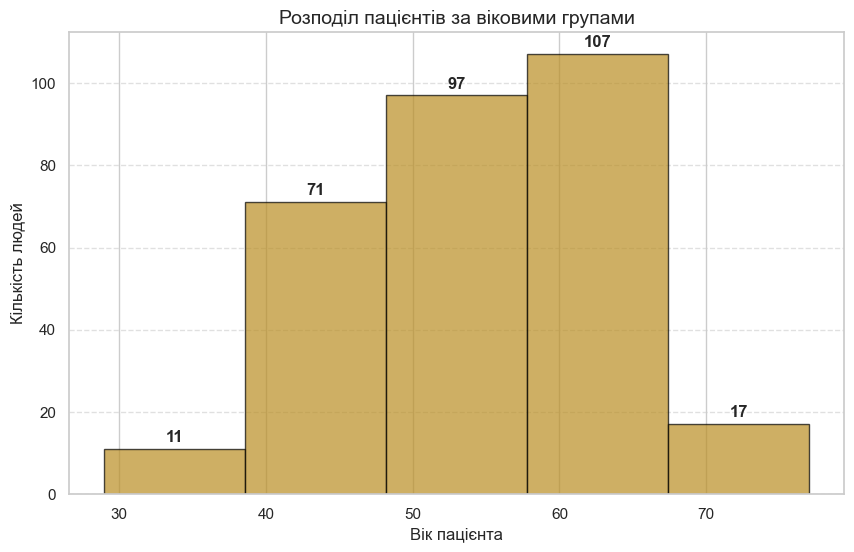

Межі сформованих вікових груп:
Група 1: від 29.0 до 38.6 років
Група 2: від 38.6 до 48.2 років
Група 3: від 48.2 до 57.8 років
Група 4: від 57.8 до 67.4 років
Група 5: від 67.4 до 77.0 років


In [33]:
plt.figure(figsize=(10, 6))

counts, bins, patches = plt.hist(df['age'], bins=5, color='#BA8E23', edgecolor='black', alpha=0.7)


for count, patch in zip(counts, patches):
    height = patch.get_height()
    plt.annotate(f'{int(count)}', 
                 xy=(patch.get_x() + patch.get_width() / 2, height),
                 xytext=(0, 5), textcoords='offset points', 
                 ha='center', weight='bold')

plt.title('Розподіл пацієнтів за віковими групами', fontsize=14)
plt.xlabel('Вік пацієнта', fontsize=12)
plt.ylabel('Кількість людей', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

# Виведемо межі груп у консоль для звіту
print("Межі сформованих вікових груп:")
for i in range(len(bins)-1):
    print(f"Група {i+1}: від {bins[i]:.1f} до {bins[i+1]:.1f} років")

# Завдання 5
Збудувати графіки, використовуючи приклади, наведені у https://medium.com/data-science/the-art-of-effective-visualization-of-multi-dimensional-data-6c7202990c57

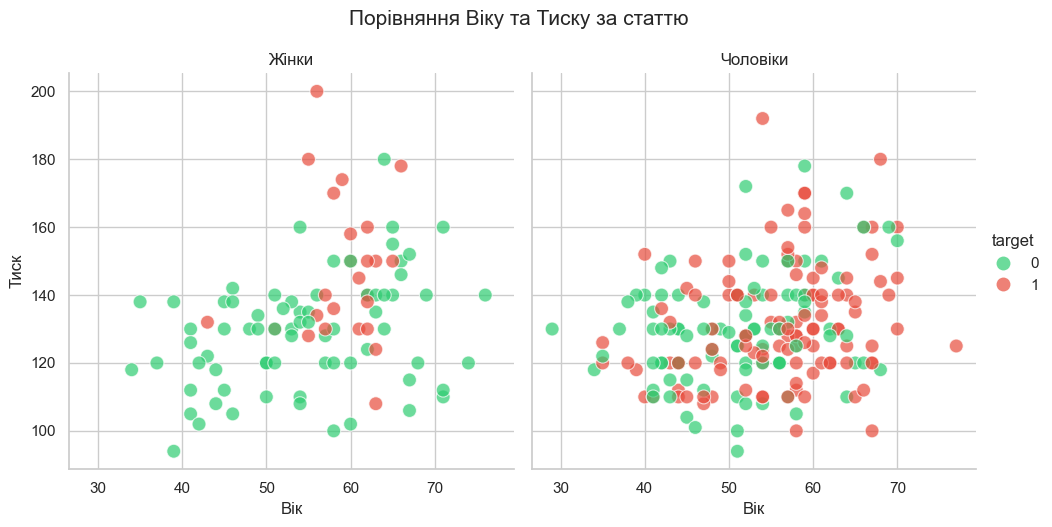

In [47]:
sns.set_theme(style="whitegrid")
target_colors = {0: "#2ecc71", 1: "#e74c3c"}

g = sns.relplot(
    data=df, 
    x="age", y="trestbps", 
    hue="target", col="sex",
    palette=target_colors, 
    s=100, alpha=0.7,
    kind="scatter"
)

# Налаштування заголовків для кожної колонки
axes = g.axes.flatten()
axes[0].set_title("Жінки")
axes[1].set_title("Чоловіки")

g.fig.suptitle('Порівняння Віку та Тиску за статтю', fontsize=15, y=1.05)
g.set_axis_labels("Вік", "Тиск")
plt.show()

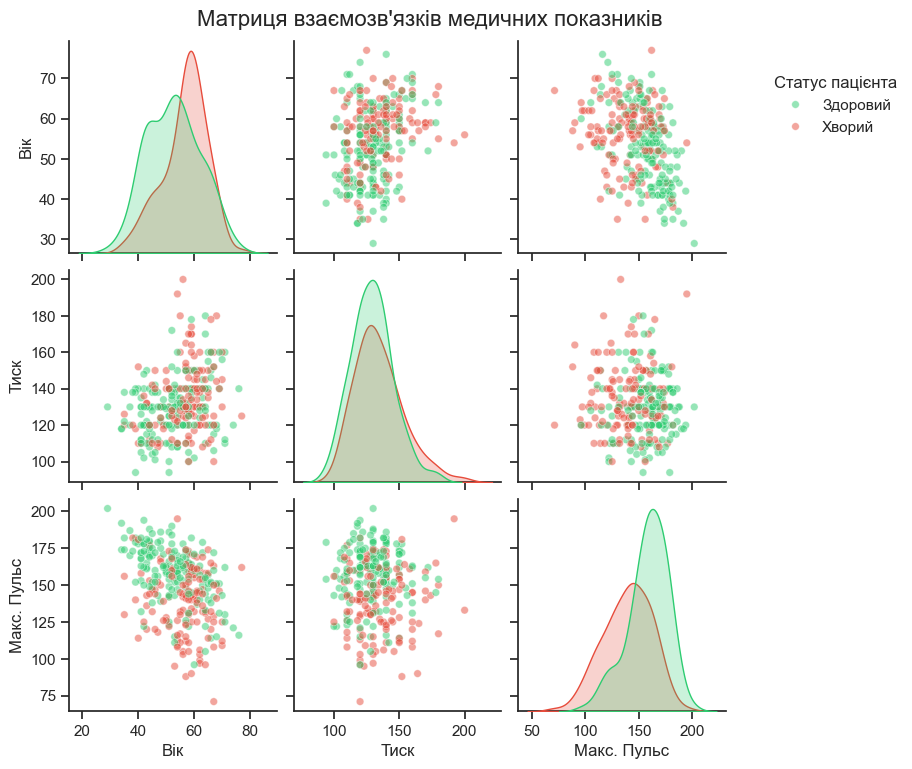

In [49]:
sns.set_theme(style="ticks")
target_colors = {0: "#2ecc71", 1: "#e74c3c"}

plot_df = df[['age', 'trestbps', 'thalach', 'target']].copy()
plot_df.columns = ['Вік', 'Тиск', 'Макс. Пульс', 'Діагноз']
plot_df['Діагноз'] = plot_df['Діагноз'].map({0: 'Здоровий', 1: 'Хворий'})

g = sns.pairplot(
    plot_df, 
    hue='Діагноз', 
    palette={'Здоровий': "#2ecc71", 'Хворий': "#e74c3c"},
    diag_kind="kde",
    plot_kws={'alpha': 0.5, 's': 30, 'edgecolor': 'w', 'linewidth': 0.5}
)

g.fig.suptitle('Матриця взаємозв\'язків медичних показників', fontsize=16, y=1.02)

sns.move_legend(g, "upper right", bbox_to_anchor=(1.05, 0.95), title='Статус пацієнта')

plt.show()

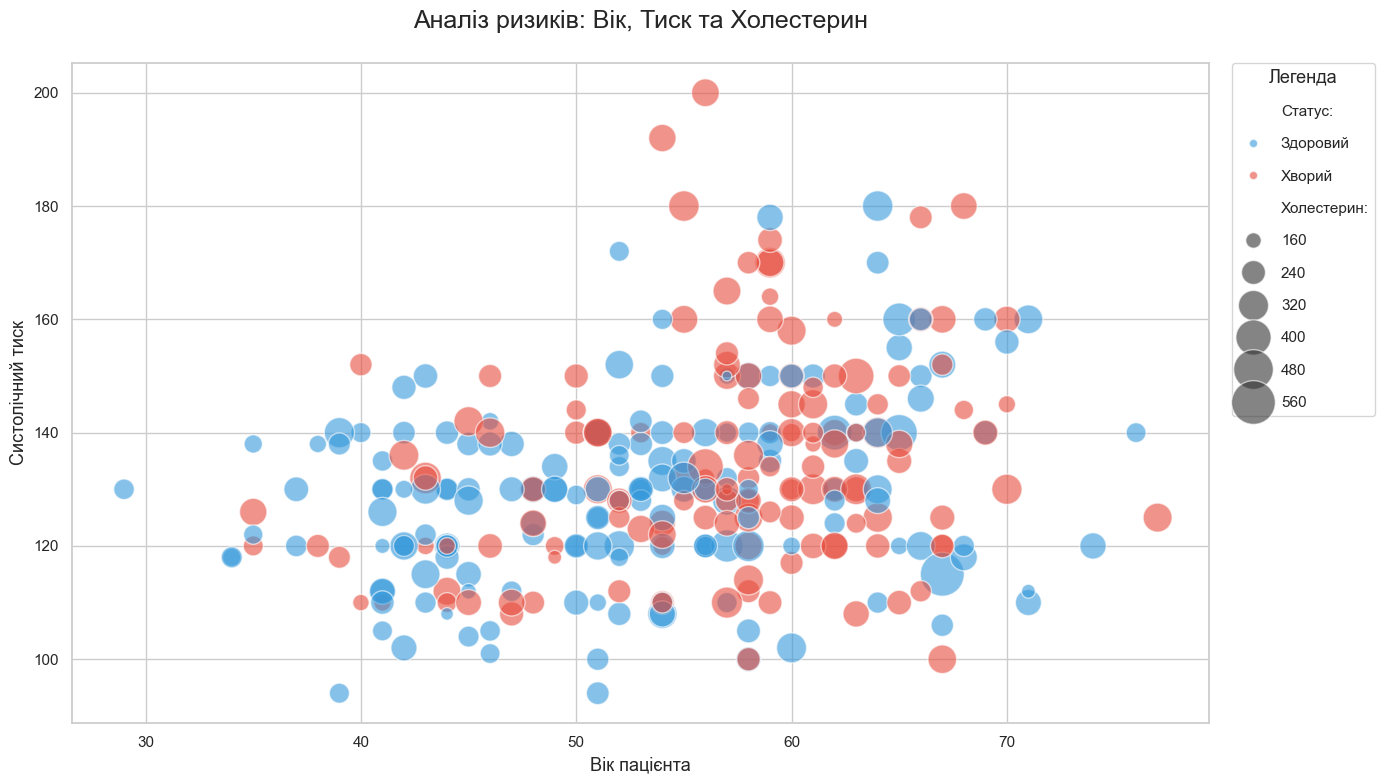

In [54]:
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

scatter = sns.scatterplot(
    data=df, 
    x='age', 
    y='trestbps', 
    size='chol',
    hue='target',      
    sizes=(50, 1000),   
    alpha=0.6,         
    palette={0: "#3498db", 1: "#e74c3c"},
    edgecolor="w",
    linewidth=1
)


plt.title('Аналіз ризиків: Вік, Тиск та Холестерин', fontsize=18, pad=25)
plt.xlabel('Вік пацієнта', fontsize=13)
plt.ylabel('Систолічний тиск', fontsize=13)

handles, labels = scatter.get_legend_handles_labels()

new_labels = []
for label in labels:
    if label == 'target':
        new_labels.append('Статус:')
    elif label == '0':
        new_labels.append('Здоровий')
    elif label == '1':
        new_labels.append('Хворий')
    elif label == 'chol':
        new_labels.append('Холестерин:')
    else:
        new_labels.append(label)


plt.legend(handles, new_labels, 
           bbox_to_anchor=(1.02, 1), 
           loc='upper left', 
           borderaxespad=0,
           title='Легенда',
           title_fontsize='13',
           labelspacing=1.2)

plt.tight_layout()
plt.show()

# Завдання 6
Побудувати інші графіки, що покажуть корисну інформацію про датасет. Загальна кількість графіків має становити 5-8.

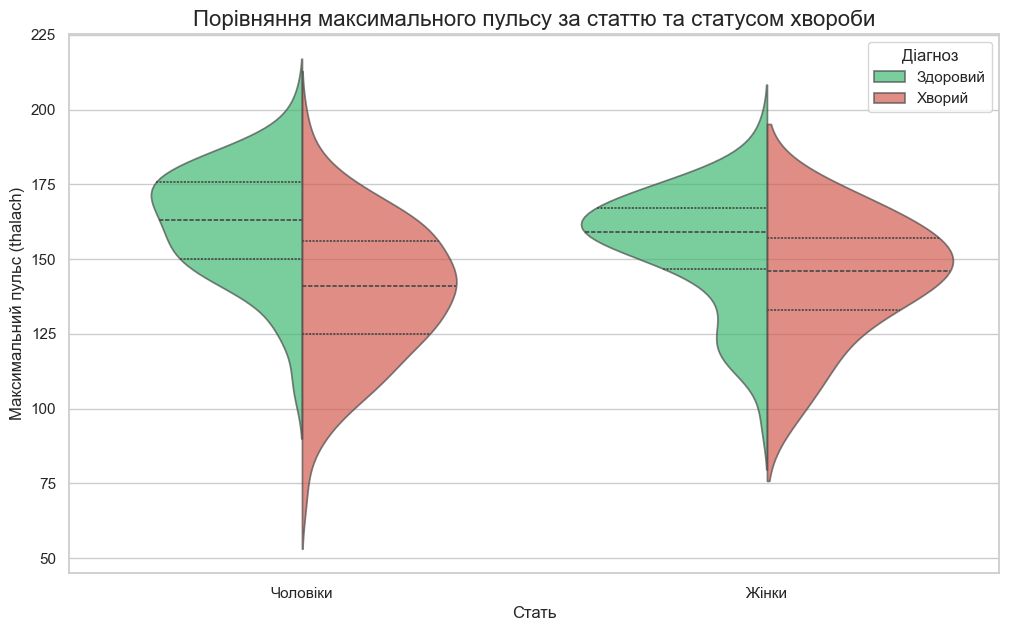

In [57]:
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

plot_df = df.copy()
plot_df['Статус'] = plot_df['target'].map({0: 'Здоровий', 1: 'Хворий'})
plot_df['Стать'] = plot_df['sex'].map({0: 'Жінки', 1: 'Чоловіки'})

sns.violinplot(
    data=plot_df, 
    x='Стать', 
    y='thalach',
    hue='Статус', 
    split=True,
    inner="quartile",
    palette={'Здоровий': "#2ecc71", 'Хворий': "#e74c3c"},
    alpha=0.7
)

plt.title('Порівняння максимального пульсу за статтю та статусом хвороби', fontsize=16)
plt.xlabel('Стать', fontsize=12)
plt.ylabel('Максимальний пульс (thalach)', fontsize=12)
plt.legend(title='Діагноз')

plt.show()

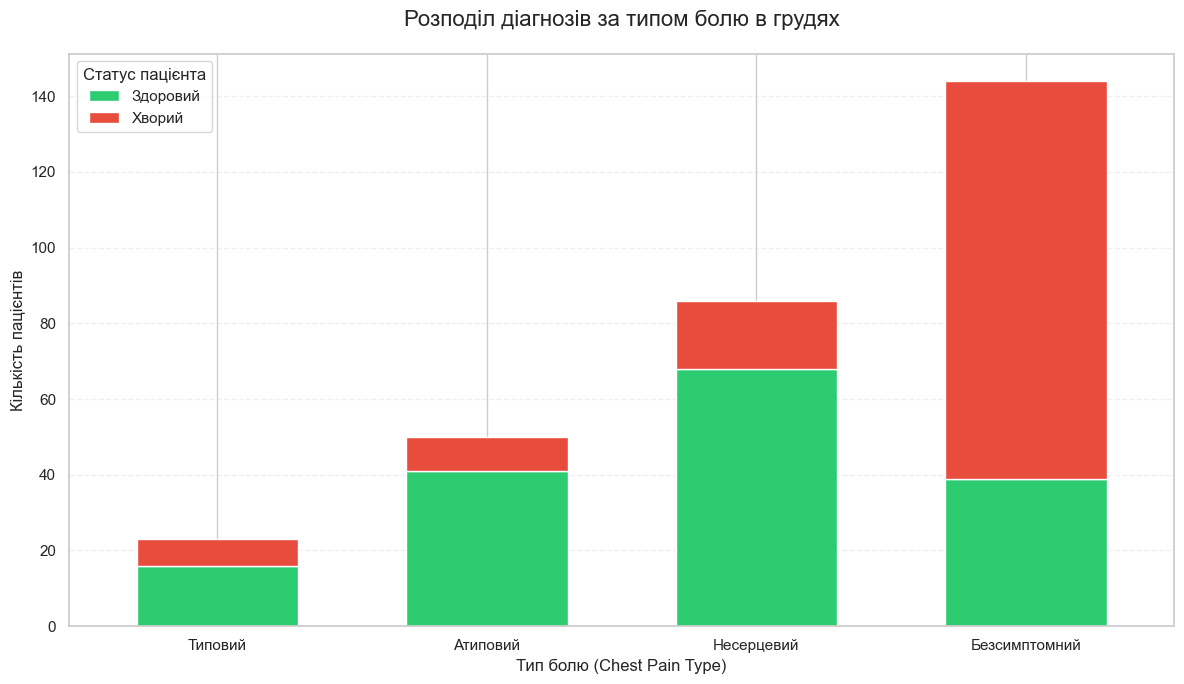

In [60]:
bar_df = df.copy()

cp_values = sorted(bar_df['cp'].unique())
cp_labels = {
    cp_values[0]: 'Типовий',
    cp_values[1]: 'Атиповий',
    cp_values[2]: 'Несерцевий',
    cp_values[3]: 'Безсимптомний'
}

pivot_df = bar_df.groupby(['cp', 'target']).size().unstack(fill_value=0)
pivot_df.columns = ['Здоровий', 'Хворий']
pivot_df.index = pivot_df.index.map(cp_labels)

plt.figure(figsize=(12, 7))
pivot_df.plot(kind='bar', stacked=True, color=["#2ecc71", "#e74c3c"], ax=plt.gca(), width=0.6)

plt.title('Розподіл діагнозів за типом болю в грудях', fontsize=16, pad=20)
plt.xlabel('Тип болю (Chest Pain Type)', fontsize=12)
plt.ylabel('Кількість пацієнтів', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Статус пацієнта', frameon=True)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()